#### Fragmentation Index — Weekly-or-more-frequent tasks only
#### By: Peyman Shahidi (robustness build)
#### Created: 2026-06-25

**Purpose.** Test whether the fragmentation-index result survives when we keep **only ONET tasks that are
performed on a weekly basis or more frequently**, dropping infrequently-executed tasks that may contaminate
the LLM-generated workflows.

**Frequency definition.** ONET's *Frequency of Task* (`FT`) scale has seven categories. "Weekly or more
frequently" maps to the four highest categories: *More than weekly*, *Daily*, *Several times daily*, and
*Hourly or more*. For each task ONET reports the share of incumbents in each category; we keep a task when the
combined share in these four categories is at least `FREQ_THRESHOLD` percent (default 50% — i.e. a majority of
incumbents do the task at least weekly).

**Method.** We *prune the existing workflows* (we do **not** re-query the LLM): we drop infrequent tasks from
each occupation's task sequence, preserve the relative order of the surviving tasks, then recompute the
fragmentation index and re-run the regression. This directly answers "what fraction of the tasks in the
original workflows were infrequent, and do the results survive removing them?"

This notebook runs the **full** pipeline first (reproducing the baseline) and then the **frequent-only**
pipeline, and prints a side-by-side comparison.

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

pd.set_option('float_format', "{:,.2f}".format)
pd.set_option('display.max_rows', 200)
import warnings; warnings.filterwarnings('ignore')

In [2]:
# ====================== PARAMETERS ======================
# Weekly-or-more frequency cut (share of incumbents reporting the task at least weekly)
FREQ_THRESHOLD = 50.0            # percent; majority rule

my_onet_level = 'detailed'
onet_occupation_code_var = 'Detailed_Occupation_Code'
onet_occupation_title_var = 'Detailed_Occupation_Title'
ai_exposure_var = 'human_E1_fraction'

# ONET FT categories that count as "weekly or more frequently"
WEEKLY_PLUS_COLS = ['FT_More than weekly', 'FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']

# Occupations must retain at least this many tasks to compute a fragmentation index
MIN_TASKS_PER_OCC = 3

In [3]:
main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
input_file_path = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"

# Write new outputs to a dedicated folder so baseline artifacts are untouched
output_data_path = f"{input_data_path}/computed_objects/fragmentationIndex_weeklyTasks"
output_plot_path = f"{main_folder_path}/writeup/plots/fragmentationIndex_weeklyTasks"
for p in [output_data_path, output_plot_path]:
    os.makedirs(p, exist_ok=True)

In [4]:
# SOC mappings (for fixed effects) from the cleaned task file
ONET = pd.read_csv(f"{input_data_path}/computed_objects/ONET_cleaned_tasks.csv")
SOC_mappings = ONET[['O*NET-SOC Code', 'Occupation Title',
                     'Major_Group_Code', 'Major_Group_Title',
                     'Minor_Group_Code', 'Minor_Group_Title',
                     'Broad_Occupation_Code', 'Broad_Occupation_Title',
                     'Detailed_Occupation_Code', 'Detailed_Occupation_Title']].copy()
SOC_mappings = SOC_mappings.drop_duplicates(subset=['O*NET-SOC Code', onet_occupation_code_var])

## Helper functions (identical logic to the baseline `onet_fragmentationIndex.ipynb`)

In [5]:
def create_occupation_analysis(df, onet_occupation_code_var, onet_occupation_title_var):
    occupation_stats = []
    for (soc_code, occ_title), group in df.groupby([onet_occupation_code_var, onet_occupation_title_var]):
        num_tasks = group['Task ID'].nunique()
        total_tasks = len(group)
        manual_fraction = (group['label'] == 'Manual').sum() / total_tasks
        augmentation_fraction = (group['label'] == 'Augmentation').sum() / total_tasks
        automation_fraction = (group['label'] == 'Automation').sum() / total_tasks
        ai_fraction = augmentation_fraction + automation_fraction
        gpt4_E1_fraction = (group['gpt4_exposure'] == 'E1').sum() / total_tasks
        gpt4_E2_fraction = (group['gpt4_exposure'] == 'E2').sum() / total_tasks
        human_E1_fraction = (group['human_labels'] == 'E1').sum() / total_tasks
        human_E2_fraction = (group['human_labels'] == 'E2').sum() / total_tasks
        occupation_stats.append({
            onet_occupation_code_var: soc_code, onet_occupation_title_var: occ_title,
            'num_tasks': num_tasks, 'manual_fraction': manual_fraction, 'ai_fraction': ai_fraction,
            'augmentation_fraction': augmentation_fraction, 'automation_fraction': automation_fraction,
            'gpt4_E1_fraction': gpt4_E1_fraction, 'gpt4_E2_fraction': gpt4_E2_fraction,
            'gpt4_aiExposure_fraction': gpt4_E1_fraction + gpt4_E2_fraction,
            'human_E1_fraction': human_E1_fraction, 'human_E2_fraction': human_E2_fraction,
            'human_aiExposure_fraction': human_E1_fraction + human_E2_fraction})
    return pd.DataFrame(occupation_stats)


def construct_fragmentation_index(df, desired_definition=1, save_filename=None):
    # Defn 1: AI chain = Automation->(Automation|Augmentation); switches between AI-chains and Manual
    # Defn 2: any AI task (Aug|Auto); Defn 3: exposure label E1; Defn 4: exposure label E1|E2
    fi_df = df.copy()
    if desired_definition != 1:
        if desired_definition == 2:
            fi_df['is_ai'] = fi_df['label'].isin(['Augmentation', 'Automation']).astype(int)
        elif desired_definition == 3:
            fi_df['is_ai'] = fi_df['human_labels'].isin(['E1']).astype(int)
        elif desired_definition == 4:
            fi_df['is_ai'] = fi_df['human_labels'].isin(['E1', 'E2']).astype(int)
        fi_df['next_is_ai'] = fi_df.groupby(['O*NET-SOC Code', 'Occupation Title'])['is_ai'].shift(-1).fillna(0).astype(int)
        fi_df['num_switches'] = 1
        fi_df.loc[(fi_df['is_ai'] == 1) & (fi_df['next_is_ai'] == 1), 'num_switches'] = 0
    else:
        fi_df['is_automated'] = fi_df['label'].isin(['Automation']).astype(int)
        fi_df['is_augmented'] = fi_df['label'].isin(['Augmentation']).astype(int)
        fi_df['next_is_automated'] = fi_df.groupby(['O*NET-SOC Code', 'Occupation Title'])['is_automated'].shift(-1).fillna(0).astype(int)
        fi_df['next_is_augmented'] = fi_df.groupby(['O*NET-SOC Code', 'Occupation Title'])['is_augmented'].shift(-1).fillna(0).astype(int)
        fi_df['num_switches'] = 1
        chain = (fi_df['is_automated'] == 1) & ((fi_df['next_is_automated'] == 1) | (fi_df['next_is_augmented'] == 1))
        fi_df.loc[chain, 'num_switches'] = 0
    fi_df = fi_df.groupby(['O*NET-SOC Code', 'Occupation Title'])['num_switches'].mean().reset_index().rename(columns={'num_switches': 'fragmentation_index'})
    if save_filename:
        fi_df.to_csv(f"{output_data_path}/{save_filename}", index=False)
    return fi_df


def merge_fragmentation_with_occupation_analysis(fi_df, occupation_analysis, SOC_mappings, onet_occupation_code_var, save_filename=None):
    occupation_analysis = occupation_analysis.merge(fi_df, on=['O*NET-SOC Code', 'Occupation Title'], how='left')
    if save_filename:
        occupation_analysis.to_csv(f"{output_data_path}/{save_filename}", index=False)
    occupation_analysis = occupation_analysis.merge(SOC_mappings, on=['O*NET-SOC Code', 'Occupation Title'], how='left')
    return occupation_analysis


def aggregate_occupation_analysis(occupation_analysis, onet_occupation_code_var, onet_occupation_title_var, SOC_mappings, ai_exposure_var):
    agg = occupation_analysis.groupby([onet_occupation_code_var, onet_occupation_title_var]).agg({
        'fragmentation_index': 'mean', ai_exposure_var: 'mean', 'ai_fraction': 'mean', 'num_tasks': 'mean'}).reset_index()
    agg = agg.merge(SOC_mappings, on=onet_occupation_code_var, how='left', suffixes=('', '_drop'))
    agg = agg.loc[:, ~agg.columns.str.endswith('_drop')]
    return agg

In [6]:
def prepare_merged(apply_freq):
    '''Load merged workflow data; optionally prune to weekly-or-more tasks (preserving order).
    Then drop occupations left with < MIN_TASKS_PER_OCC tasks (matches the baseline >=3 rule).'''
    df = pd.read_csv(input_file_path)
    n_rows_all = len(df)
    df['weekly_plus'] = df[WEEKLY_PLUS_COLS].sum(axis=1)
    df['is_frequent'] = df['weekly_plus'] >= FREQ_THRESHOLD
    if apply_freq:
        df = df[df['is_frequent']].reset_index(drop=True)
    # keep occupations with enough tasks to define a sequence/index
    counts = df.groupby('O*NET-SOC Code')['Task ID'].nunique()
    valid = counts[counts >= MIN_TASKS_PER_OCC].index
    df = df[df['O*NET-SOC Code'].isin(valid)].reset_index(drop=True)
    return df, n_rows_all


def run_all_definitions(merged_data, tag):
    '''Exposure-based FI definitions 3 & 4 x {no FE, Major FE, Minor FE} (execution-based 1 & 2 dropped).
    Returns the list of fitted models (6 = 2 definitions x 3 specs).'''
    results = []
    for definition in [3, 4]:
        occ = create_occupation_analysis(merged_data, 'O*NET-SOC Code', 'Occupation Title')
        fi = construct_fragmentation_index(merged_data, desired_definition=definition,
                                           save_filename=f'fragmentationIndex_{tag}_def{definition}.csv')
        occ = merge_fragmentation_with_occupation_analysis(fi, occ, SOC_mappings, onet_occupation_code_var,
                                                           save_filename=f'occupation_analysis_{tag}_def{definition}.csv')
        agg = aggregate_occupation_analysis(occ, onet_occupation_code_var, onet_occupation_title_var, SOC_mappings, ai_exposure_var)
        agg = agg.rename(columns={ai_exposure_var: 'ai_exposure'})
        for _scol in ('Major_Group_Code', 'Minor_Group_Code', onet_occupation_code_var):
            if _scol in agg.columns:
                agg[_scol] = agg[_scol].astype('object')
        for _col in ['ai_fraction', 'ai_exposure', 'fragmentation_index']:
            s = agg[_col]; agg[_col] = (s - s.mean()) / s.std()
        clu = dict(cov_type="cluster", cov_kwds={"groups": agg[onet_occupation_code_var],
                                                 "use_correction": True, "df_correction": True})
        results.append(smf.ols('ai_fraction ~ fragmentation_index + ai_exposure', data=agg).fit(**clu))
        results.append(smf.ols('ai_fraction ~ fragmentation_index + ai_exposure + C(Major_Group_Code)', data=agg).fit(**clu))
        results.append(smf.ols('ai_fraction ~ fragmentation_index + ai_exposure + C(Minor_Group_Code)', data=agg).fit(**clu))
    return results

## Step 1 — How many workflow tasks are infrequent? (the headline diagnostic)

In [7]:
raw = pd.read_csv(input_file_path)
raw['weekly_plus'] = raw[WEEKLY_PLUS_COLS].sum(axis=1)
raw['is_frequent'] = raw['weekly_plus'] >= FREQ_THRESHOLD
n_all = len(raw); n_freq = int(raw['is_frequent'].sum()); n_infreq = n_all - n_freq
print(f"Original workflow task-rows: {n_all:,}")
print(f"  weekly-or-more (kept):     {n_freq:,}  ({n_freq/n_all*100:.1f}%)")
print(f"  infrequent (dropped):      {n_infreq:,}  ({n_infreq/n_all*100:.1f}%)   <-- fraction of workflow tasks that were not frequently executed")
print()
print("Sensitivity of the kept/dropped split to the threshold:")
for t in [40, 50, 60, 65, 70, 80]:
    k = int((raw['weekly_plus'] >= t).sum())
    print(f"  weekly+ >= {t:>2}% : keep {k:>6,} ({k/n_all*100:4.1f}%) | drop {n_all-k:>6,} ({(n_all-k)/n_all*100:4.1f}%)")

# Per-occupation share of infrequent tasks
occ_share = raw.groupby('O*NET-SOC Code')['is_frequent'].agg(['mean', 'size'])
occ_share['infrequent_share'] = 1 - occ_share['mean']
print(f"\nAcross {len(occ_share):,} occupations, share of tasks that are infrequent:")
print(occ_share['infrequent_share'].describe()[['mean', '25%', '50%', '75%', 'max']].round(3).to_string())

Original workflow task-rows: 17,925
  weekly-or-more (kept):     11,662  (65.1%)
  infrequent (dropped):      6,263  (34.9%)   <-- fraction of workflow tasks that were not frequently executed

Sensitivity of the kept/dropped split to the threshold:
  weekly+ >= 40% : keep 13,110 (73.1%) | drop  4,815 (26.9%)
  weekly+ >= 50% : keep 11,662 (65.1%) | drop  6,263 (34.9%)
  weekly+ >= 60% : keep 10,069 (56.2%) | drop  7,856 (43.8%)
  weekly+ >= 65% : keep  9,248 (51.6%) | drop  8,677 (48.4%)
  weekly+ >= 70% : keep  8,389 (46.8%) | drop  9,536 (53.2%)
  weekly+ >= 80% : keep  6,379 (35.6%) | drop 11,546 (64.4%)

Across 872 occupations, share of tasks that are infrequent:
mean   0.33
25%    0.08
50%    0.27
75%    0.55
max    1.00


## Step 2 — Run the pipeline on the FULL sample (baseline reproduction) and the FREQUENT sample

In [8]:
merged_full, _ = prepare_merged(apply_freq=False)
merged_freq, _ = prepare_merged(apply_freq=True)
print(f"FULL    : {merged_full['O*NET-SOC Code'].nunique():,} occupations, {len(merged_full):,} task-rows")
print(f"FREQUENT: {merged_freq['O*NET-SOC Code'].nunique():,} occupations, {len(merged_freq):,} task-rows "
      f"(occupations dropped for < {MIN_TASKS_PER_OCC} frequent tasks: "
      f"{merged_full['O*NET-SOC Code'].nunique() - merged_freq['O*NET-SOC Code'].nunique():,})")

res_full = run_all_definitions(merged_full, 'full')
res_freq = run_all_definitions(merged_freq, 'frequent')

FULL    : 872 occupations, 17,925 task-rows
FREQUENT: 833 occupations, 11,617 task-rows (occupations dropped for < 3 frequent tasks: 39)


In [9]:
# Compact comparison: fragmentation_index coefficient (the key regressor) across the 6 exposure-based specs
defs = ['v3','v3','v3','v4','v4','v4']
fes  = ['none','Major','Minor']*2
def grab(models):
    out = []
    for m in models:
        b = m.params.get('fragmentation_index', np.nan)
        se = m.bse.get('fragmentation_index', np.nan)
        p = m.pvalues.get('fragmentation_index', np.nan)
        out.append((b, se, p))
    return out
gf, gq = grab(res_full), grab(res_freq)
rows = []
for i in range(6):
    star = lambda p: '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    rows.append({'FI def': defs[i], 'FE': fes[i],
                 'full beta': f"{gf[i][0]:.2f}{star(gf[i][2])}", 'full se': f"({gf[i][1]:.2f})",
                 'freq beta': f"{gq[i][0]:.2f}{star(gq[i][2])}", 'freq se': f"({gq[i][1]:.2f})"})
cmp_frag = pd.DataFrame(rows)
print("Fragmentation-index coefficient (standardized), exposure-based defs v3 & v4 — dep var = AI execution fraction\n")
print(cmp_frag.to_string(index=False))
print("\nN (occupations):  full =", int(res_full[0].nobs), " frequent =", int(res_freq[0].nobs))
cmp_frag.to_csv(f"{output_data_path}/frag_coef_comparison_full_vs_frequent.csv", index=False)

Fragmentation-index coefficient (standardized), exposure-based defs v3 & v4 — dep var = AI execution fraction

FI def    FE full beta full se freq beta freq se
    v3  none      0.02  (0.08)      0.15  (0.09)
    v3 Major     -0.06  (0.07)     -0.04  (0.09)
    v3 Minor     -0.01  (0.06)     -0.03  (0.08)
    v4  none  -0.37***  (0.05)  -0.33***  (0.05)
    v4 Major  -0.34***  (0.06)   -0.16**  (0.06)
    v4 Minor  -0.23***  (0.06)    -0.13*  (0.06)

N (occupations):  full = 872  frequent = 851


In [10]:
# Also report the ai_exposure (control) coefficient for completeness
def grab_var(models, var):
    return [(m.params.get(var, np.nan), m.pvalues.get(var, np.nan)) for m in models]
ef, eq = grab_var(res_full, 'ai_exposure'), grab_var(res_freq, 'ai_exposure')
star = lambda p: '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
print("ai_exposure coefficient (standardized):")
for i in range(6):
    print(f"  def {defs[i]:<2} FE={fes[i]:<5}: full {ef[i][0]:+.2f}{star(ef[i][1]):<3}   frequent {eq[i][0]:+.2f}{star(eq[i][1])}")

ai_exposure coefficient (standardized):
  def v3 FE=none : full +0.57***   frequent +0.59***
  def v3 FE=Major: full +0.17**    frequent +0.20***
  def v3 FE=Minor: full +0.16**    frequent +0.18**
  def v4 FE=none : full +0.29***   frequent +0.27***
  def v4 FE=Major: full +0.12**    frequent +0.19***
  def v4 FE=Minor: full +0.10**    frequent +0.16**


## Step 3 — Full regression table (frequent sample), saved as LaTeX

Exposure-based definitions only: **FI v3** (exposure E1) in columns 1–3 and **FI v4** (exposure E1|E2, the
preferred specification) in columns 4–6, each with {no FE, Major-group FE, Minor-group FE}.

In [11]:
info_dict = {
    'N': lambda x: f"{int(x.nobs):,}",
    'SOC Group Fixed Effects': lambda x: (
        '' if 'C(Major_Group_Code)' not in x.model.formula and 'C(Minor_Group_Code)' not in x.model.formula
        else 'Major' if 'C(Major_Group_Code)' in x.model.formula else 'Minor')}
regressor_order = ['ai_exposure', 'fragmentation_index']

def make_table(models, names):
    return summary_col(results=models, float_format='%0.2f', stars=True, model_names=names,
                       info_dict=info_dict, regressor_order=regressor_order, drop_omitted=True)

t = make_table(res_freq, ['(1)','(2)','(3)','(4)','(5)','(6)'])
with open(f"{output_data_path}/fragmentation_index_regression_frequent_v3v4.tex", "w") as f: f.write(t.as_latex())
print("FREQUENT-SAMPLE TABLE — FI v3 (cols 1-3) & FI v4 (cols 4-6), each {no FE, Major, Minor}:\n")
print(t)

FREQUENT-SAMPLE TABLE — FI v3 (cols 1-3) & FI v4 (cols 4-6), each {no FE, Major, Minor}:


                          (1)     (2)    (3)     (4)      (5)    (6)  
----------------------------------------------------------------------
ai_exposure             0.59*** 0.20*** 0.18** 0.27***  0.19*** 0.16**
                        (0.08)  (0.08)  (0.08) (0.06)   (0.06)  (0.06)
fragmentation_index     0.15    -0.04   -0.03  -0.33*** -0.16** -0.13*
                        (0.09)  (0.09)  (0.08) (0.05)   (0.06)  (0.06)
R-squared               0.23    0.54    0.62   0.29     0.55    0.63  
R-squared Adj.          0.23    0.52    0.56   0.29     0.53    0.57  
N                       851     851     851    851      851     851   
SOC Group Fixed Effects         Major   Minor           Major   Minor 
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Step 4 — Filtering-logic × threshold sweep: how the headline moves as we slice the sequences differently

We now vary **both** the filtering *logic* (which ONET `FT` frequency bucket a task must reach) **and** the
*threshold* (what share of incumbents must report that frequency). The logics, from most inclusive to most
restrictive:

| logic | ONET FT categories kept |
|---|---|
| Monthly+        | 3–7 (More than monthly → Hourly) |
| Weekly+         | 4–7 (More than weekly → Hourly) |
| Daily+          | 5–7 (Daily, Several times daily, Hourly or more) |
| SeveralDaily+   | 6–7 (Several times daily, Hourly or more) |
| Hourly+         | 7   (Hourly or more) |

Each logic is swept over thresholds **20 / 35 / 50 / 65%**. As in the main spec, **all three variables**
(AI-execution share, fragmentation index, AI exposure) are **z-scored within each cut**, so every coefficient
reads as "a 1-SD increase in the fragmentation index is associated with a β-SD change in the AI-execution
share." Cells where the cut leaves too little data to estimate are left blank. `N` = occupations.

In [12]:
# Filtering logics (cumulative FT tails), inclusive -> restrictive, plus the threshold grid
FAMILIES = [
    ('Daily+',        'daily',    ['FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']),   # FT 5-7
    ('SeveralDaily+', 'sevdaily', ['FT_Several times daily', 'FT_Hourly or more']),               # FT 6-7
    ('Hourly+',       'hourly',   ['FT_Hourly or more']),                                          # FT 7
]
SWEEP_THRESHOLDS = [20, 35, 50, 65]
CUTS = [('All tasks', 'all', None, None)]
for lab, tag, cols in FAMILIES:
    for t in SWEEP_THRESHOLDS:
        CUTS.append((f"{lab} >={t}%", tag, cols, t))

# --- neighbor sample's occupation set per cut (so fragmentation is estimated on the SAME occupations as the neighbor analysis) ---
_dwa_map = pd.read_csv(f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv")
_uniq = _dwa_map.groupby('Task ID')['DWA ID'].nunique().reset_index(name='_n')
_single_dwa = _uniq[_uniq['_n'] == 1]['Task ID'].tolist()
_ALLFT = ['FT_Yearly or less', 'FT_More than yearly', 'FT_More than monthly', 'FT_More than weekly',
          'FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']
_npool = pd.read_csv(input_file_path)[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title', 'Task Position', 'label'] + _ALLFT].copy()
_npool['is_ai'] = _npool['label'].isin(['Augmentation', 'Automation']).astype(int)
_npool['Task Position'] = pd.to_numeric(_npool['Task Position'], errors='coerce')
_npool = _npool.merge(_dwa_map, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
_npool = _npool[_npool['Task ID'].isin(_single_dwa)].drop_duplicates(subset=['O*NET-SOC Code', 'Task ID'])
_npool = _npool[~_npool['DWA ID'].isna()]
_oc = _npool.groupby('DWA ID')['O*NET-SOC Code'].nunique(); _npool = _npool[_npool['DWA ID'].isin(_oc[_oc > 1].index)]

def neighbor_occ_set(family_cols, threshold):
    """Occupations in the neighbor regression sample for this cut: O*NET-SOC codes that retain a
    fully-neighbored task (t-2..t+2 all defined) after the DWA filters + frequency filter."""
    d = _npool if family_cols is None else _npool[_npool[family_cols].sum(axis=1) >= threshold]
    d = d.sort_values(['O*NET-SOC Code', 'Task Position'])
    g = d.groupby('O*NET-SOC Code')['is_ai']
    fl = pd.concat([g.shift(1), g.shift(2), g.shift(-1), g.shift(-2)], axis=1)
    return set(d[fl.notna().all(axis=1)]['O*NET-SOC Code'])

def prepare_cut(family_cols, threshold):
    df = pd.read_csv(input_file_path)
    if family_cols is not None:
        df = df[df[family_cols].sum(axis=1) >= threshold].reset_index(drop=True)
    # Restrict to the neighbor sample's occupations (comparable samples); FI still computed over each
    # occupation's FULL frequency-filtered task sequence (the workflow).
    df = df[df['O*NET-SOC Code'].isin(neighbor_occ_set(family_cols, threshold))].reset_index(drop=True)
    return df

def headline_raw(merged_data):
    '''Standardized (z-scored) fragmentation_index coefficient for exposure-based defs 3,4 x {no FE, Major, Minor}.
    All three regression variables are z-scored within the cut (as in the main spec).
    Returns NaNs for a (def, FE) cell that cannot be estimated (too few occupations / no variation).'''
    out = {}
    for definition in [3, 4]:
        try:
            occ = create_occupation_analysis(merged_data, 'O*NET-SOC Code', 'Occupation Title')
            fi = construct_fragmentation_index(merged_data, desired_definition=definition)
            occ = merge_fragmentation_with_occupation_analysis(fi, occ, SOC_mappings, onet_occupation_code_var)
            agg = aggregate_occupation_analysis(occ, onet_occupation_code_var, onet_occupation_title_var, SOC_mappings, ai_exposure_var)
            agg = agg.rename(columns={ai_exposure_var: 'ai_exposure'})
            for _c in ('Major_Group_Code', 'Minor_Group_Code', onet_occupation_code_var):
                agg[_c] = agg[_c].astype('object')
            for _z in ['ai_fraction', 'ai_exposure', 'fragmentation_index']:   # z-score all three (interpretable betas)
                _s = agg[_z]; _sd = _s.std()
                agg[_z] = (_s - _s.mean()) / _sd if (_sd and not np.isnan(_sd)) else np.nan
            n_occ = int(len(agg))
            clu = dict(cov_type="cluster", cov_kwds={"groups": agg[onet_occupation_code_var], "use_correction": True, "df_correction": True})
        except Exception:
            for fe_name in ['none', 'Major', 'Minor']:
                out[(definition, fe_name)] = (np.nan, np.nan, np.nan, 0)
            continue
        for fe_name, fe_term in [('none', ''), ('Major', ' + C(Major_Group_Code)'), ('Minor', ' + C(Minor_Group_Code)')]:
            try:
                if n_occ < 10 or agg['fragmentation_index'].nunique() < 2:
                    raise ValueError('too small')
                m = smf.ols(f'ai_fraction ~ fragmentation_index + ai_exposure{fe_term}', data=agg).fit(**clu)
                out[(definition, fe_name)] = (m.params['fragmentation_index'], m.bse['fragmentation_index'],
                                              m.pvalues['fragmentation_index'], n_occ)
            except Exception:
                out[(definition, fe_name)] = (np.nan, np.nan, np.nan, n_occ)
    return out

sweep_rows = []
for label, fam, cols, thr in CUTS:
    md_cut = prepare_cut(cols, thr)
    res = headline_raw(md_cut)
    for (definition, fe_name), (b, se, p, n) in res.items():
        sweep_rows.append({'cut': label, 'family': fam, 'threshold': thr if thr is not None else 0, 'FI_def': f'v{definition}',
                           'FE': fe_name, 'coef': b, 'se': se, 'pval': p, 'N_occ': n})
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(f"{output_data_path}/frag_logic_threshold_sweep.csv", index=False)
print("Saved sweep to frag_logic_threshold_sweep.csv  (", len(sweep), "rows )")
print("Baseline (all tasks) FI v4 no-FE coef:",
      round(sweep[(sweep.family=='all')&(sweep.FI_def=='v4')&(sweep.FE=='none')]['coef'].iloc[0], 2))

Saved sweep to frag_logic_threshold_sweep.csv  ( 78 rows )
Baseline (all tasks) FI v4 no-FE coef: -0.37


In [13]:
# Grid table (rows = logic, cols = threshold) of the standardized (z-scored) fragmentation_index coef, with stars + N.
# Row 0 = "All tasks" (no pruning) — the most relaxed cut, i.e. the spec currently reported in the paper.
# It has no threshold, so its (constant) value is repeated across all threshold columns.
star = lambda p: '***' if (pd.notna(p) and p<0.01) else '**' if (pd.notna(p) and p<0.05) else '*' if (pd.notna(p) and p<0.1) else ''
fam_order = ['daily', 'sevdaily', 'hourly']
fam_label = {'daily':'Daily+', 'sevdaily':'SeveralDaily+', 'hourly':'Hourly+'}
row_order = ['all'] + fam_order
row_label = {'all':'All tasks', **fam_label}
FI_DEF_TITLE = {'v4':'FI v4 (exposure E1|E2) — MAIN', 'v3':'FI v3 (exposure E1 only)'}

def _cell(sub, fam, t):
    x = sub[sub['family']=='all'] if fam == 'all' else sub[(sub['family']==fam) & (sub['threshold']==t)]
    if len(x) and pd.notna(x['coef'].iloc[0]):
        return x['coef'].iloc[0], x['pval'].iloc[0], int(x['N_occ'].iloc[0])
    return None

def grid_table(definition, fe):
    sub = sweep[(sweep['FI_def']==definition) & (sweep['FE']==fe)]
    rows = []
    for fam in row_order:
        r = {'logic': row_label[fam]}
        for t in SWEEP_THRESHOLDS:
            c = _cell(sub, fam, t)
            r[f'>={t}%'] = f"{c[0]:.2f}{star(c[1])} (N={c[2]})" if c else "—"
        rows.append(r)
    return pd.DataFrame(rows)

FE_SPECS = [('none', 'Baseline (no FE)', 'baseline'),
            ('Major', 'Major SOC group FE', 'majorFE'),
            ('Minor', 'Minor SOC group FE', 'minorFE')]
# Main definition (FI v4) across the three regression specs, then FI v3:
for d in ['v4', 'v3']:
    for fe_code, fe_name, _tag in FE_SPECS:
        print(f"\n{FI_DEF_TITLE[d]} — {fe_name} (top row = paper's all-tasks spec):\n")
        print(grid_table(d, fe_code).to_string(index=False))


FI v4 (exposure E1|E2) — MAIN — Baseline (no FE) (top row = paper's all-tasks spec):

        logic            >=20%            >=35%            >=50%            >=65%
    All tasks -0.37*** (N=866) -0.37*** (N=866) -0.37*** (N=866) -0.37*** (N=866)
       Daily+ -0.36*** (N=817) -0.44*** (N=700)  -0.19** (N=567)  -0.20** (N=419)
SeveralDaily+ -0.19*** (N=519) -0.28*** (N=341) -0.41*** (N=199)  -0.25*** (N=97)
      Hourly+ -0.35*** (N=307)  -0.33** (N=145)      0.02 (N=64)                —

FI v4 (exposure E1|E2) — MAIN — Major SOC group FE (top row = paper's all-tasks spec):

        logic            >=20%            >=35%            >=50%            >=65%
    All tasks -0.34*** (N=866) -0.34*** (N=866) -0.34*** (N=866) -0.34*** (N=866)
       Daily+ -0.20*** (N=817) -0.28*** (N=700)    -0.11 (N=567) -0.32*** (N=419)
SeveralDaily+    -0.13 (N=519) -0.31*** (N=341)   -0.37* (N=199)     -0.65 (N=97)
      Hourly+ -0.47*** (N=307)   -0.49* (N=145)      0.18 (N=64)                —

FI 

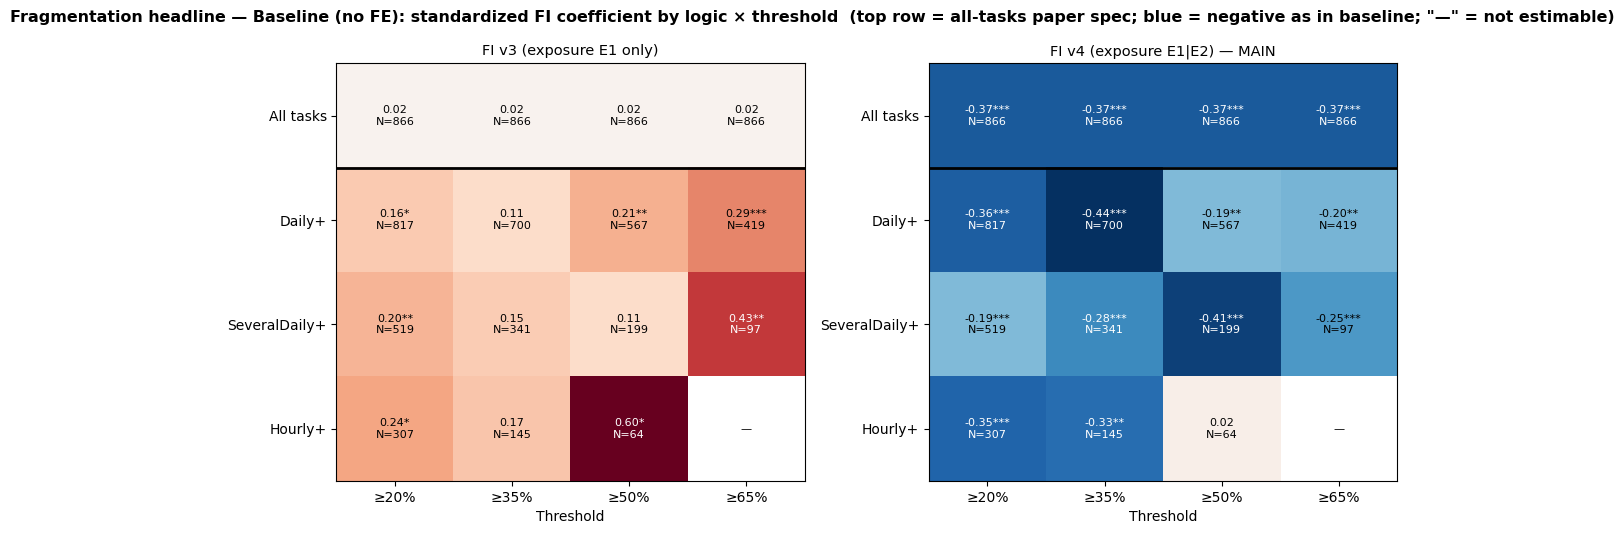

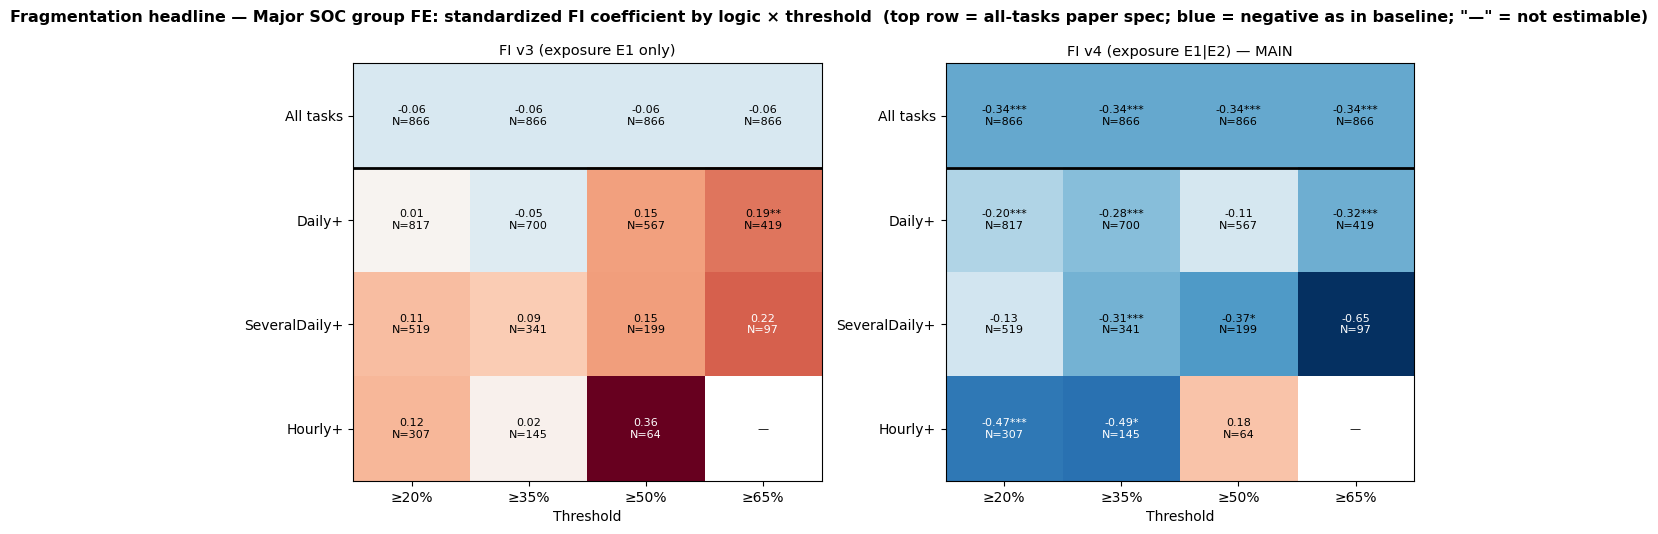

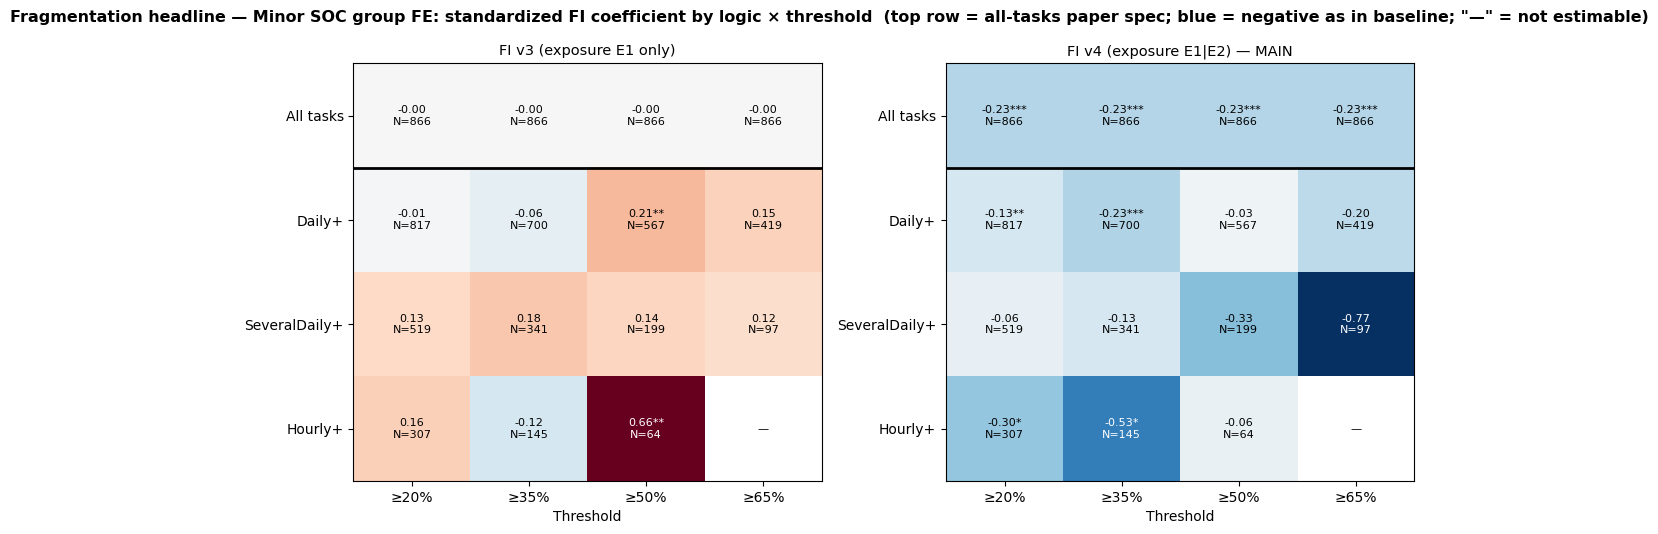

Saved 3 per-spec heatmap figures (baseline / majorFE / minorFE) to ../writeup/plots/fragmentationIndex_weeklyTasks


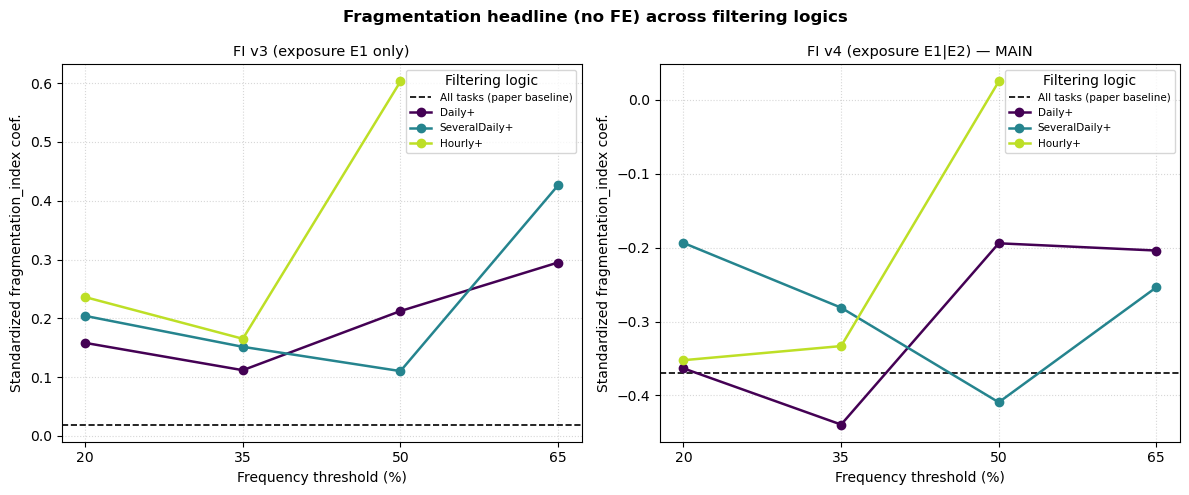

Saved heatmap + line figures to ../writeup/plots/fragmentationIndex_weeklyTasks


In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def heatmap(ax, definition, fe, title):
    sub = sweep[(sweep['FI_def']==definition) & (sweep['FE']==fe)]
    M = np.full((len(row_order), len(SWEEP_THRESHOLDS)), np.nan)
    ann = [['—' for _ in SWEEP_THRESHOLDS] for _ in row_order]
    for i, fam in enumerate(row_order):
        for j, t in enumerate(SWEEP_THRESHOLDS):
            c = _cell(sub, fam, t)
            if c:
                M[i, j] = c[0]; ann[i][j] = f"{c[0]:.2f}{star(c[1])}\nN={c[2]}"
    vmax = np.nanmax(np.abs(M)) if np.isfinite(M).any() else 1.0
    ax.imshow(M, cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax), aspect='auto')
    ax.set_xticks(range(len(SWEEP_THRESHOLDS))); ax.set_xticklabels([f"≥{t}%" for t in SWEEP_THRESHOLDS])
    ax.set_yticks(range(len(row_order))); ax.set_yticklabels([row_label[f] for f in row_order])
    ax.axhline(0.5, color='black', lw=2)  # separate the paper's all-tasks baseline row
    for i in range(len(row_order)):
        for j in range(len(SWEEP_THRESHOLDS)):
            ax.text(j, i, ann[i][j], ha='center', va='center', fontsize=8,
                    color='black' if (np.isnan(M[i,j]) or abs(M[i,j])<0.6*vmax) else 'white')
    ax.set_title(title, fontsize=10.5); ax.set_xlabel('Threshold')

# One heatmap figure per regression spec (baseline / Major FE / Minor FE); each = FI v3 (left) and FI v4 (right)
for fe_code, fe_name, fe_tag in FE_SPECS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
    for ax, d in zip(axes, ['v3', 'v4']):
        heatmap(ax, d, fe_code, FI_DEF_TITLE[d])
    fig.suptitle(f'Fragmentation headline — {fe_name}: standardized FI coefficient by logic × threshold  (top row = all-tasks paper spec; blue = negative as in baseline; "—" = not estimable)', fontweight='bold', fontsize=11.5)
    fig.tight_layout()
    fig.savefig(f"{output_plot_path}/frag_logic_threshold_heatmap_{fe_tag}.png", dpi=200, bbox_inches='tight')
    plt.show()
print("Saved 3 per-spec heatmap figures (baseline / majorFE / minorFE) to", output_plot_path)

# Line view: FI coef vs threshold, one line per logic, panel per definition (baseline = dashed line)
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(fam_order)))
for ax, d in zip(axes2, ['v3', 'v4']):
    sub = sweep[(sweep['FI_def']==d) & (sweep['FE']=='none')]
    base = sub[sub['family']=='all']['coef'].iloc[0]
    ax.axhline(base, color='black', ls='--', lw=1.2, label='All tasks (paper baseline)')
    for fam, c in zip(fam_order, cmap):
        s = sub[sub['family']==fam].sort_values('threshold').dropna(subset=['coef'])
        if len(s): ax.plot(s['threshold'], s['coef'], marker='o', color=c, lw=1.8, label=fam_label[fam])
    ax.set_title(FI_DEF_TITLE[d], fontsize=10.5); ax.set_xlabel('Frequency threshold (%)')
    ax.set_ylabel('Standardized fragmentation_index coef.'); ax.set_xticks(SWEEP_THRESHOLDS)
    ax.grid(True, ls=':', alpha=0.5); ax.legend(fontsize=7.5, title='Filtering logic')
fig2.suptitle('Fragmentation headline (no FE) across filtering logics', fontweight='bold')
fig2.tight_layout(); fig2.savefig(f"{output_plot_path}/frag_logic_threshold_lines.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved heatmap + line figures to", output_plot_path)

## Takeaways

- **Step 1** — headline diagnostic: the share of tasks in the original LLM workflows that are *not* performed
  at least weekly (i.e. dropped under the cut).
- **Step 2** — fragmentation-index coefficient (standardized) full vs. frequent-only across the exposure-based
  definitions FI v3 & v4 × {no FE, Major, Minor}; robust if sign and significance hold (precision falls as the
  sample shrinks).
- **Step 4** — filtering-logic × threshold sweep of the standardized (z-scored) headline coefficient across the logics
  (Monthly+/Weekly+/Daily+/SeveralDaily+/Hourly+) × four thresholds (20/35/50/65%). Heatmaps are produced
  **separately for each regression spec** — `frag_logic_threshold_heatmap_baseline.png` (no FE),
  `_majorFE.png`, `_minorFE.png` — each showing **FI v3 (left) and FI v4 (right, main)** panels, plus a line plot.
- Outputs are written to `data/computed_objects/fragmentationIndex_weeklyTasks/` and the sweep figures to
  `writeup/plots/fragmentationIndex_weeklyTasks/`.